# Cabo Verde coherent vortices

The FTLE ridges in `cabo_verde_ftle` mark hyperbolic stretching. A coherent
Lagrangian vortex is a different structure: a region that keeps its shape as
it advects, bounded by a curve that neither converges nor diverges from its
neighbours. Haller (2015, §5.2 / Table 1, row "Shear",
[doi:10.1146/annurev-fluid-010313-141322](https://doi.org/10.1146/annurev-fluid-010313-141322))
builds such curves from the same Cauchy–Green tensor
$C = (\nabla F)^\top \nabla F$, eigenpairs $C\xi_i = \lambda_i \xi_i$,
$0 < \lambda_1 \le \lambda_2$. A *shear line* is tangent everywhere to
(Eq. 11)

$$
\eta^{\pm} = \sqrt{\frac{\sqrt{\lambda_2}}{\sqrt{\lambda_1}+\sqrt{\lambda_2}}}\,\xi_1
  \;\pm\; \sqrt{\frac{\sqrt{\lambda_1}}{\sqrt{\lambda_1}+\sqrt{\lambda_2}}}\,\xi_2 \,.
$$

A closed shear line is an **elliptic LCS**; the outermost member of a nested
family of closed shear lines is the boundary of a coherent Lagrangian vortex.
Eq. 11 keeps a material curve's arc length fixed under an area-preserving
flow. The Cabo Verde surface flow is not area-preserving over 5 days
(`docs/numerics.md` reports $\det\nabla F$ ranging over roughly 0.63–2.4), so
this notebook uses the $\lambda$-generalisation instead (Haller & Beron-Vera
2013, Eq. 14,
[doi:10.1017/jfm.2013.391](https://doi.org/10.1017/jfm.2013.391)):

$$
\eta_\lambda^{\pm} = \sqrt{\frac{\lambda_2 - \lambda^2}{\lambda_2 - \lambda_1}}\,\xi_1
  \;\pm\; \sqrt{\frac{\lambda^2 - \lambda_1}{\lambda_2 - \lambda_1}}\,\xi_2 \,,
$$

well defined only where $\lambda_1 < \lambda^2 < \lambda_2$. A closed orbit
of $\eta_\lambda$ is a material curve that stretches by the uniform factor
$\lambda$ over the window; Eq. 11 is the $\lambda=1$ member. This notebook
scans a small set of $\lambda$ near 1 and both signs, since the boundary can
show up at any of them.

Detection follows Haller & Beron-Vera (2013): a short Poincaré section
through a candidate centre, $\eta_\lambda$ lines launched along it and
integrated to their first return, and the return map $s \mapsto P(s)$ read
off the section. A fixed point $P(s) = s$ is a closed orbit.

In [1]:
# Importing Parcels pulls in the holoviews/bokeh bootstrap and prints an
# alpha-version notice, neither of which belongs on the rendered page.
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from matplotlib.path import Path as MplPath
from parcels import FieldSet, Particle, ParticleSet, StatusCode
from parcels.convert import copernicusmarine_to_sgrid
from parcels.kernels import AdvectionRK4
from scipy.interpolate import RegularGridInterpolator

from lcs_parcels import NeighborSeedGrid
from lcs_parcels.grids import _M_PER_DEG, _separation_m
from lcs_parcels.tensorlines import _step_lonlat_by_meters

/var/folders/w1/m9mm9h9167z_gcfzfffr0rgsh6j6kj/T/ipykernel_5484/590446562.py:7: UserWarning: This is an alpha version of Parcels v4. The API is not stable and may change without deprecation warnings.
  from parcels import FieldSet, Particle, ParticleSet, StatusCode


## Currents

The local file that `get_data` writes.

In [2]:
currents = xr.open_dataset("data/cabo_verde_currents_hourly.nc").load()
currents

<xarray.Dataset> Size: 53MB
Dimensions:    (time: 289, depth: 1, latitude: 145, longitude: 157)
Coordinates:
  * time       (time) datetime64[ns] 2kB 2025-07-31 ... 2025-08-12
  * depth      (depth) float32 4B 0.494
  * latitude   (latitude) float32 580B 10.0 10.08 10.17 ... 21.83 21.92 22.0
  * longitude  (longitude) float32 628B -30.5 -30.42 -30.33 ... -17.58 -17.5
Data variables:
    uo         (time, depth, latitude, longitude) float32 26MB 0.144 ... -0.1622
    vo         (time, depth, latitude, longitude) float32 26MB -0.1292 ... -0...
Attributes:
    Conventions:               CF-1.8
    area:                      Global
    contact:                   https://marine.copernicus.eu/contact
    credit:                    E.U. Copernicus Marine Service Information (CM...
    institution:               Mercator Ocean International
    licence:                   http://marine.copernicus.eu/services-portfolio...
    producer:                  CMEMS - Global Monitoring and Forecasting Centre
    references:                http://marine.copernicus.eu
    source:                    MOI GLO12
    title:                     hourly mean fields from Global Ocean Physics A...
    copernicusmarine_version:  2.4.1

## Parcels v4 field set

`copernicusmarine_to_sgrid` tags the CMEMS A-grid with SGRID metadata;
`from_sgrid_conventions` wraps it as a spherical `FieldSet`.

In [3]:
sgrid = copernicusmarine_to_sgrid(fields={"U": currents["uo"], "V": currents["vo"]})
fieldset = FieldSet.from_sgrid_conventions(sgrid, mesh="spherical")
z_surface = float(currents["depth"].values[0])

## Seed grid and window

Same box, resolution, $t_0$ and $T$ as `cabo_verde_ftle`. Only the forward
flow map is needed, since a vortex boundary is a property of one time
window, not of the forward/backward pair `cabo_verde_lcs` uses for
repelling/attracting duality.

In [4]:
t0 = np.datetime64("2025-08-06")
T = np.timedelta64(5, "D")
resolution_deg = 1 / 25
seed_lon, seed_lat = (-27.0, -21.0), (13.5, 18.5)

lon_axis = np.arange(seed_lon[0], seed_lon[1] + 1e-9, resolution_deg)
lat_axis = np.arange(seed_lat[0], seed_lat[1] + 1e-9, resolution_deg)
seed = NeighborSeedGrid.from_axes(lon=lon_axis, lat=lat_axis)
seed

<NeighborSeedGrid 151x126 grid, lon -27.00..-21.00, lat 13.50..18.50>

## Recovery kernel

Particles that leave the domain or hit land are turned into `NaN` in place
(Parcels would otherwise abort the run), so losses propagate as `NaN`
through every diagnostic below. `StatusCode.EndofLoop` rather than
`StatusCode.Delete`: deleting shrinks the particle array and breaks the
alignment with the seed order.

In [5]:
def set_lost_to_nan(particles, fieldset):
    lost = particles.state >= StatusCode.Error
    particles.x = np.where(lost, np.nan, particles.x)
    particles.y = np.where(lost, np.nan, particles.y)
    particles.state = np.where(lost, StatusCode.EndofLoop, particles.state)

## Advect forward

In [6]:
lon, lat = seed.to_parcels_pset()
z = np.full(len(lon), z_surface)
pset = ParticleSet(fieldset, pclass=Particle, x=lon, y=lat, z=z, t=t0)
pset.execute(
    [AdvectionRK4, set_lost_to_nan],
    dt=np.timedelta64(1, "h"),
    runtime=T,
    verbose_progress=False,
)
forward = seed.pset_to_flowmap(lon=pset.x, lat=pset.y, t0=t0, t1=t0 + T)
forward

<NeighborFlowMap 151x126 grid, lon -27.00..-21.00, lat 13.50..18.50,
                 t0 2025-08-06T00:00:00, T +5.0 days>

## Eigendecomposition and FTLE

`cg_eigen` carries $\lambda_1,\lambda_2$ and $\xi_1,\xi_2$ together; `ftle`
is the backdrop the candidate centres and the closed orbits are shown
against below.

In [7]:
eigen = forward.cg_eigen()
eigen

<xarray.Dataset> Size: 1MB
Dimensions:   (i: 151, j: 126, eig: 2, comp: 2)
Coordinates:
  * i         (i) int64 1kB 0 1 2 3 4 5 6 7 ... 143 144 145 146 147 148 149 150
  * j         (j) int64 1kB 0 1 2 3 4 5 6 7 ... 118 119 120 121 122 123 124 125
    lon_grid  (i, j) float64 152kB -27.0 -27.0 -27.0 -27.0 ... -21.0 -21.0 -21.0
    lat_grid  (i, j) float64 152kB 13.5 13.54 13.58 13.62 ... 18.42 18.46 18.5
  * eig       (eig) int64 16B 0 1
  * comp      (comp) <U1 8B 'x' 'y'
    t0        datetime64[s] 8B 2025-08-06
    T         timedelta64[s] 8B 5 days
Data variables:
    lambda    (i, j, eig) float64 304kB nan nan nan nan nan ... nan nan nan nan
    xi        (i, j, comp, eig) float64 609kB nan nan nan nan ... nan nan nan

In [8]:
ftle = forward.ftle()
ftle

<xarray.DataArray 'ftle' (i: 151, j: 126)> Size: 152kB
array([[           nan,            nan,            nan, ...,
                   nan,            nan,            nan],
       [           nan, 1.35797213e-06, 1.23527600e-06, ...,
        4.40692559e-07, 4.79924914e-07,            nan],
       [           nan, 1.49540361e-06, 1.36816813e-06, ...,
        4.68802660e-07, 5.29881192e-07,            nan],
       ...,
       [           nan, 4.70773490e-07, 5.30224314e-07, ...,
        1.49028367e-06, 1.45351069e-06,            nan],
       [           nan, 5.14297214e-07, 6.16961180e-07, ...,
        1.58231754e-06, 1.56025693e-06,            nan],
       [           nan,            nan,            nan, ...,
                   nan,            nan,            nan]], shape=(151, 126))
Coordinates:
  * i         (i) int64 1kB 0 1 2 3 4 5 6 7 ... 143 144 145 146 147 148 149 150
  * j         (j) int64 1kB 0 1 2 3 4 5 6 7 ... 118 119 120 121 122 123 124 125
    lon_grid  (i, j) float64 152kB -27.0 -27.0 -27.0 -27.0 ... -21.0 -21.0 -21.0
    lat_grid  (i, j) float64 152kB 13.5 13.54 13.58 13.62 ... 18.42 18.46 18.5
    t0        datetime64[s] 8B 2025-08-06
    T         timedelta64[s] 8B 5 days
Attributes:
    long_name:  finite-time Lyapunov exponent
    units:      1/s

## The $\eta_\lambda$ tangent field

`lcs_parcels.tensorlines` hard-wires its tracer to $\xi_1$
(`shrink_lines`); there is no public hook for a caller-supplied tangent
field, so this cell builds one from scratch rather than reusing library
code, mirroring `_shrink_line_tangent`'s structure: interpolate $C$ itself
rather than the eigenvectors, re-diagonalise at every evaluation, and orient
the result to the running heading, since an eigenvector carries no sign of
its own.

In [9]:
lon_grid_axis = forward.lon_grid.isel(j=0).values
lat_grid_axis = forward.lat_grid.isel(i=0).values
CG_grid = forward.cauchy_green().transpose("i", "j", "row", "col").values
tensor_interp = RegularGridInterpolator(
    (lon_grid_axis, lat_grid_axis), CG_grid, bounds_error=False, fill_value=np.nan
)


def eta_lambda_tangent(lon, lat, heading, *, lam, sign, tensor_interp):
    """Unit eta_lambda^{sign} (Haller & Beron-Vera 2013, Eq. 14) at each point.

    NaN wherever off-grid, in a NaN cell, or lam**2 does not sit strictly
    inside (lambda_1, lambda_2), the well-definedness condition for eta_lambda.
    """
    C = tensor_interp(np.column_stack([lon, lat]))
    terminated = ~np.isfinite(C).all(axis=(1, 2))
    eigenvalues, eigenvectors = np.linalg.eigh(
        np.where(terminated[:, None, None], np.eye(2), C)
    )
    lam1, lam2 = np.maximum(eigenvalues[:, 0], 0.0), eigenvalues[:, 1]
    well_defined = (lam1 < lam**2) & (lam**2 < lam2)
    terminated = terminated | ~well_defined
    denom = np.maximum(lam2 - lam1, 1e-30)
    a = np.sqrt(np.clip((lam2 - lam**2) / denom, 0.0, 1.0))
    b = np.sqrt(np.clip((lam**2 - lam1) / denom, 0.0, 1.0))
    xi1, xi2 = eigenvectors[:, :, 0], eigenvectors[:, :, 1]
    eta = sign * (a[:, None] * xi1 + b[:, None] * xi2)
    eta[np.sum(eta * heading, axis=1) < 0] *= -1
    eta[terminated] = np.nan
    return eta

## RK2 tracer

Marches $\eta_\lambda$ one direction from a set of launch points, the
midpoint (RK2) scheme `shrink_lines` uses, sharing its spherical step
`_step_lonlat_by_meters` (imported from `lcs_parcels.tensorlines`, private
because the package exposes no public tangent-field stepper).

In [10]:
def trace_eta_lines(lon0, lat0, *, lam, sign, step_m, n_steps, tensor_interp):
    lon = np.asarray(lon0, dtype=float).ravel().copy()
    lat = np.asarray(lat0, dtype=float).ravel().copy()
    heading = eta_lambda_tangent(
        lon,
        lat,
        np.ones((lon.size, 2)),
        lam=lam,
        sign=sign,
        tensor_interp=tensor_interp,
    )
    dead = ~np.isfinite(heading).all(axis=1)
    lon[dead], lat[dead] = np.nan, np.nan
    track_lon, track_lat = [lon.copy()], [lat.copy()]
    for _ in range(n_steps):
        direction = eta_lambda_tangent(
            lon, lat, heading, lam=lam, sign=sign, tensor_interp=tensor_interp
        )
        mid_lon, mid_lat = _step_lonlat_by_meters(
            lon, lat, 0.5 * direction, step_m=step_m
        )
        mid_direction = eta_lambda_tangent(
            mid_lon, mid_lat, direction, lam=lam, sign=sign, tensor_interp=tensor_interp
        )
        lon, lat = _step_lonlat_by_meters(lon, lat, mid_direction, step_m=step_m)
        heading = mid_direction
        track_lon.append(lon.copy())
        track_lat.append(lat.copy())
    return np.array(track_lon), np.array(track_lat)  # (n_steps + 1, n)

## Where $\eta_\lambda$ is well defined, at $\lambda = 1$

$\eta_1$ needs $\lambda_1 < 1 < \lambda_2$: everywhere the flow both
stretches and contracts a neighbourhood, which excludes the small patches
where the window happens to be exactly area-preserving in one eigen-plane.

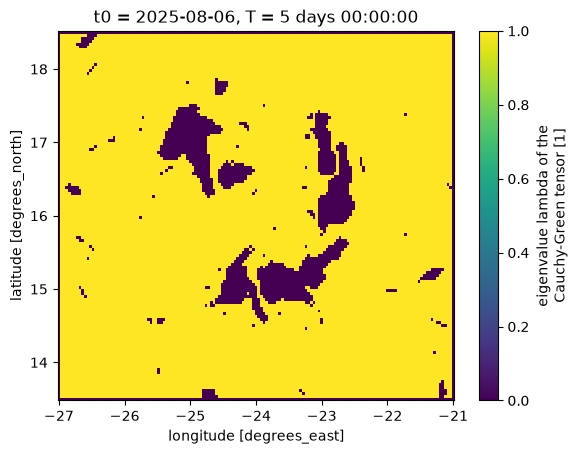

In [11]:
lambda1 = eigen["lambda"].isel(eig=0)
lambda2 = eigen["lambda"].isel(eig=1)
well_defined = (lambda1 < 1.0) & (1.0 < lambda2)
well_defined.plot.pcolormesh(x="lon_grid", y="lat_grid")

## Candidate vortex centres

A coherent vortex core is where material barely stretches at all in either
eigendirection, so $\lambda_2$ (the larger, more discriminating of the two)
is at a local minimum. `find_centres` below is the `ftle_ridge_seeds`
windowed-extremum trick inverted to a minimum, plus a validity guard that
keeps a centre 50 km from the domain edge and from any NaN (land) cell,
since the tensor there is unreliable.

In [12]:
def find_centres(field, *, window_m, edge_m):
    lon_grid, lat_grid = field["lon_grid"], field["lat_grid"]
    dx, _ = _separation_m(
        lon_a=lon_grid.shift(i=1),
        lat_a=lat_grid.shift(i=1),
        lon_b=lon_grid,
        lat_b=lat_grid,
    )
    _, dy = _separation_m(
        lon_a=lon_grid.shift(j=1),
        lat_a=lat_grid.shift(j=1),
        lon_b=lon_grid,
        lat_b=lat_grid,
    )
    spacing_i, spacing_j = float(np.abs(dx).median()), float(np.abs(dy).median())
    cells_i = max(
        1, round(window_m / spacing_i) - (round(window_m / spacing_i) % 2 == 0)
    )
    cells_j = max(
        1, round(window_m / spacing_j) - (round(window_m / spacing_j) % 2 == 0)
    )
    local_min = field.rolling(i=cells_i, j=cells_j, center=True, min_periods=1).min()
    is_centre = field <= local_min

    edge_cells_i = int(np.ceil(edge_m / spacing_i))
    edge_cells_j = int(np.ceil(edge_m / spacing_j))
    ni, nj = field.sizes["i"], field.sizes["j"]
    valid_window = (
        field.notnull()
        .astype(float)
        .rolling(
            i=2 * edge_cells_i + 1, j=2 * edge_cells_j + 1, center=True, min_periods=1
        )
        .min()
    )
    i_idx, j_idx = (
        xr.DataArray(np.arange(ni), dims="i"),
        xr.DataArray(np.arange(nj), dims="j"),
    )
    near_edge = (
        (i_idx < edge_cells_i)
        | (i_idx >= ni - edge_cells_i)
        | (j_idx < edge_cells_j)
        | (j_idx >= nj - edge_cells_j)
    )
    keep = is_centre & field.notnull() & (valid_window > 0.5) & ~near_edge
    picked = (
        xr.Dataset({"lon": lon_grid, "lat": lat_grid, "value": field})
        .stack(pt=("i", "j"))
        .where(keep.stack(pt=("i", "j")), drop=True)
    )
    return picked["lon"].values, picked["lat"].values, picked["value"].values

In [13]:
centre_lon, centre_lat, centre_lambda2 = find_centres(
    lambda2, window_m=100_000.0, edge_m=50_000.0
)
len(centre_lon)

10

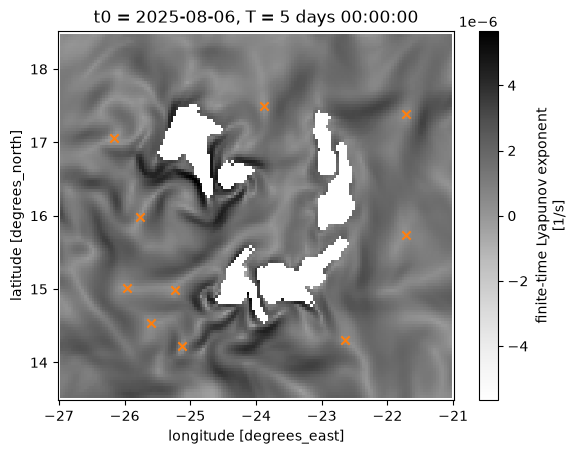

In [14]:
fig, ax = plt.subplots()
ftle.plot.pcolormesh(x="lon_grid", y="lat_grid", ax=ax, cmap="Greys")
ax.scatter(centre_lon, centre_lat, marker="x", color="tab:orange")
plt.show()

## Poincaré section and return map

A section of 40 launch points running due east from the first candidate
centre, 150 km long. `first_return` walks each traced line and finds the
first crossing of the section latitude after the line has moved away from
it, linearly interpolating the crossing longitude. `s` and `P(s)` are both
arc length east of the centre; a fixed point of $P(s) - s$ is a closed
orbit.

In [15]:
SECTION_LENGTH_M = 150_000.0
N_LAUNCH = 40
STEP_M = 2_000.0
BUDGET_M = 2_500_000.0
N_STEPS = round(BUDGET_M / STEP_M)
LAMBDAS = list(np.linspace(0.9, 1.1, 5))
SIGNS = [+1, -1]
CLOSE_TOL_M = 2_000.0


def section_points(centre_lon, centre_lat, length_m, n):
    s = np.linspace(0.0, length_m, n)
    lon = centre_lon + s / (_M_PER_DEG * np.cos(np.deg2rad(centre_lat)))
    lat = np.full(n, centre_lat)
    return s, lon, lat


def first_return(
    track_lon, track_lat, *, section_lat, section_lon_min, section_lon_max
):
    """First crossing of the section after the line has moved off it."""
    n_steps_p1, n_lines = track_lon.shape
    north_rel = track_lat - section_lat
    result_lon = np.full(n_lines, np.nan)
    for k in range(n_lines):
        lon_k, rel_k = track_lon[:, k], north_rel[:, k]
        started_away = False
        for i in range(1, n_steps_p1):
            if not started_away:
                if not np.isfinite(rel_k[i]):
                    break
                started_away = abs(rel_k[i]) > 1e-9
                continue
            if not (np.isfinite(rel_k[i - 1]) and np.isfinite(rel_k[i])):
                break
            if rel_k[i - 1] == 0 or (np.sign(rel_k[i - 1]) != np.sign(rel_k[i])):
                t = rel_k[i - 1] / (rel_k[i - 1] - rel_k[i])
                lon_cross = lon_k[i - 1] + t * (lon_k[i] - lon_k[i - 1])
                if section_lon_min - 1e-6 <= lon_cross <= section_lon_max + 1e-6:
                    result_lon[k] = lon_cross
                break
    return result_lon

In [16]:
c_lon, c_lat = centre_lon[0], centre_lat[0]
s_vals, launch_lon, launch_lat = section_points(
    c_lon, c_lat, SECTION_LENGTH_M, N_LAUNCH
)
track_lon, track_lat = trace_eta_lines(
    launch_lon,
    launch_lat,
    lam=1.0,
    sign=+1,
    step_m=STEP_M,
    n_steps=N_STEPS,
    tensor_interp=tensor_interp,
)
ret_lon = first_return(
    track_lon,
    track_lat,
    section_lat=c_lat,
    section_lon_min=launch_lon.min(),
    section_lon_max=launch_lon.max(),
)
ret_s = (ret_lon - c_lon) * _M_PER_DEG * np.cos(np.deg2rad(c_lat))

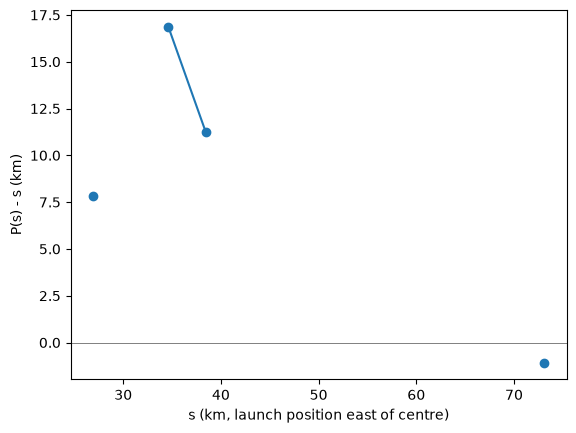

In [17]:
fig, ax = plt.subplots()
ax.plot(s_vals / 1000, (ret_s - s_vals) / 1000, marker="o")
ax.axhline(0, color="grey", lw=0.7)
ax.set_xlabel("s (km, launch position east of centre)")
ax.set_ylabel("P(s) - s (km)")
plt.show()

## Closed orbits over all $\lambda$ and signs

For every candidate centre, every $\lambda$ and both signs of $\eta_\lambda$:
find the sign changes of $P(s) - s$ across neighbouring launch points,
refine each by linear interpolation, re-trace from the refined $s$, and
accept it as a closed orbit when the residual return displacement is under
`CLOSE_TOL_M`.

A residual-only check accepts a line that merely grazes back across the
section without enclosing the centre, so every candidate also has to
enclose the centre and have a circumference within a factor of 2 of
$2\pi r$ for its mean radius $r$; both are needed, since a residual check
alone lets spurious partial loops through.

In [18]:
closed_orbits = []
n_never_return = 0

for ci, (cl, ca) in enumerate(zip(centre_lon, centre_lat, strict=True)):
    s_vals, launch_lon, launch_lat = section_points(cl, ca, SECTION_LENGTH_M, N_LAUNCH)
    lon_min, lon_max = launch_lon.min(), launch_lon.max()
    for lam in LAMBDAS:
        for sign in SIGNS:
            track_lon, track_lat = trace_eta_lines(
                launch_lon,
                launch_lat,
                lam=lam,
                sign=sign,
                step_m=STEP_M,
                n_steps=N_STEPS,
                tensor_interp=tensor_interp,
            )
            ret_lon = first_return(
                track_lon,
                track_lat,
                section_lat=ca,
                section_lon_min=lon_min,
                section_lon_max=lon_max,
            )
            ret_s = (ret_lon - cl) * _M_PER_DEG * np.cos(np.deg2rad(ca))
            if not np.isfinite(ret_s).any():
                n_never_return += 1
                continue
            P_minus_s = ret_s - s_vals
            finite = np.isfinite(P_minus_s)
            for i in range(N_LAUNCH - 1):
                if not (finite[i] and finite[i + 1]):
                    continue
                a, b = P_minus_s[i], P_minus_s[i + 1]
                if not (a == 0 or np.sign(a) != np.sign(b)):
                    continue
                t = a / (a - b)
                s_fix = s_vals[i] + t * (s_vals[i + 1] - s_vals[i])
                dlon = s_fix / (_M_PER_DEG * np.cos(np.deg2rad(ca)))
                poly_lon, poly_lat = trace_eta_lines(
                    np.array([cl + dlon]),
                    np.array([ca]),
                    lam=lam,
                    sign=sign,
                    step_m=STEP_M,
                    n_steps=N_STEPS,
                    tensor_interp=tensor_interp,
                )
                ret_lon2 = first_return(
                    poly_lon,
                    poly_lat,
                    section_lat=ca,
                    section_lon_min=lon_min,
                    section_lon_max=lon_max,
                )
                if not np.isfinite(ret_lon2[0]):
                    continue
                ret_s2 = (ret_lon2[0] - cl) * _M_PER_DEG * np.cos(np.deg2rad(ca))
                residual_m = abs(ret_s2 - s_fix)
                if residual_m >= CLOSE_TOL_M:
                    continue
                col, rel = poly_lon[:, 0], poly_lat[:, 0] - ca
                cut, started_away = len(col), False
                for ii in range(1, len(col)):
                    if not started_away:
                        if not np.isfinite(rel[ii]):
                            break
                        started_away = abs(rel[ii]) > 1e-9
                        continue
                    if not (np.isfinite(rel[ii - 1]) and np.isfinite(rel[ii])):
                        break
                    if rel[ii - 1] == 0 or np.sign(rel[ii - 1]) != np.sign(rel[ii]):
                        cut = ii + 1
                        break
                dx, dy = _separation_m(
                    lon_a=cl, lat_a=ca, lon_b=poly_lon[:cut, 0], lat_b=poly_lat[:cut, 0]
                )
                radius_m = np.hypot(dx, dy)
                mean_radius_m = float(np.nanmean(radius_m))
                encloses = MplPath(np.column_stack([dx, dy])).contains_point((0.0, 0.0))
                length_m = np.sum(
                    np.hypot(
                        np.diff(np.append(dx, dx[0])), np.diff(np.append(dy, dy[0]))
                    )
                )
                circumference_ratio = (
                    length_m / (2 * np.pi * mean_radius_m)
                    if mean_radius_m > 0
                    else np.nan
                )
                closed_orbits.append(
                    {
                        "centre_idx": ci,
                        "centre_lon": cl,
                        "centre_lat": ca,
                        "lam": lam,
                        "sign": sign,
                        "s": s_fix,
                        "residual_m": residual_m,
                        "lon": poly_lon[:cut, 0],
                        "lat": poly_lat[:cut, 0],
                        "mean_radius_m": mean_radius_m,
                        "encloses_centre": bool(encloses),
                        "circumference_ratio": float(circumference_ratio),
                    }
                )

candidate_returns = closed_orbits
closed_orbits = [
    o
    for o in candidate_returns
    if o["encloses_centre"] and 0.5 < o["circumference_ratio"] < 2.0
]
len(candidate_returns), len(closed_orbits), n_never_return

(2, 0, 32)

## Outermost orbit per centre

The outermost closed orbit, by mean radius, marks the vortex boundary at
each centre that has one.

In [19]:
outermost = {}
for o in closed_orbits:
    ci = o["centre_idx"]
    if ci not in outermost or o["mean_radius_m"] > outermost[ci]["mean_radius_m"]:
        outermost[ci] = o
len(outermost)

0

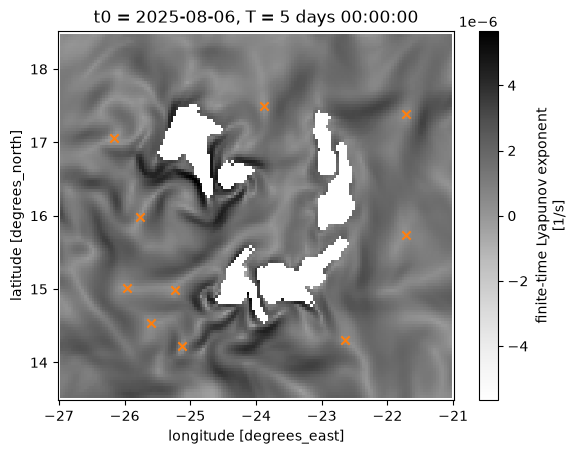

In [20]:
fig, ax = plt.subplots()
ftle.plot.pcolormesh(x="lon_grid", y="lat_grid", ax=ax, cmap="Greys")
ax.scatter(centre_lon, centre_lat, marker="x", color="tab:orange")
for o in closed_orbits:
    ax.plot(
        o["lon"],
        o["lat"],
        "-" if o["sign"] > 0 else "--",
        color="tab:green",
        lw=0.7,
        alpha=0.6,
    )
for o in outermost.values():
    ax.plot(o["lon"], o["lat"], color="tab:red", lw=2.0)
plt.show()

## Validation by advection

A closed orbit at $\lambda$ should stretch by that exact factor: advecting
every point of the curve through `flowmap.image()` (interpolating the
already-advected field, exact for this purpose, so a second Parcels run is
not needed) and re-measuring its arc length should return a ratio close to
$\lambda$, unlike a same-radius circle drawn through the centre, which has
no reason to stretch uniformly.

With zero closed orbits surviving the enclosure/circumference filter above,
there is no vortex boundary to validate. The strongest surviving return-map
fixed point before that filter is used instead, to check that the
$\eta_\lambda$ construction and stepper are numerically sound even though
this particular candidate is not a genuine closed orbit.

In [21]:
def arc_length_m(lon, lat):
    dx, dy = _separation_m(lon_a=lon[:-1], lat_a=lat[:-1], lon_b=lon[1:], lat_b=lat[1:])
    return np.sum(np.hypot(dx, dy))


def evolve_and_ratio(lon0, lat0, flowmap):
    length0 = arc_length_m(np.append(lon0, lon0[0]), np.append(lat0, lat0[0]))
    evolved = flowmap.image(
        lon_0=xr.DataArray(lon0, dims="point"), lat_0=xr.DataArray(lat0, dims="point")
    )
    lon1, lat1 = evolved["lon"].values, evolved["lat"].values
    length1 = arc_length_m(np.append(lon1, lon1[0]), np.append(lat1, lat1[0]))
    return length1 / length0, length0, length1

In [22]:
if outermost:
    boundary = next(iter(outermost.values()))
else:
    boundary = min(candidate_returns, key=lambda o: o["residual_m"])
boundary["lam"], boundary["sign"], boundary["residual_m"], boundary["encloses_centre"]

(np.float64(1.1), 1, np.float64(1051.9168859252677), False)

In [23]:
ratio, len0, len1 = evolve_and_ratio(boundary["lon"], boundary["lat"], forward)
n_circle = 60
theta = np.linspace(0, 2 * np.pi, n_circle, endpoint=False)
r_deg_lon = boundary["mean_radius_m"] / (
    _M_PER_DEG * np.cos(np.deg2rad(boundary["centre_lat"]))
)
r_deg_lat = boundary["mean_radius_m"] / _M_PER_DEG
circle_lon = boundary["centre_lon"] + r_deg_lon * np.cos(theta)
circle_lat = boundary["centre_lat"] + r_deg_lat * np.sin(theta)
circle_ratio, circle_len0, circle_len1 = evolve_and_ratio(
    circle_lon, circle_lat, forward
)
ratio, circle_ratio

(np.float64(1.1046374563555497), np.float64(nan))

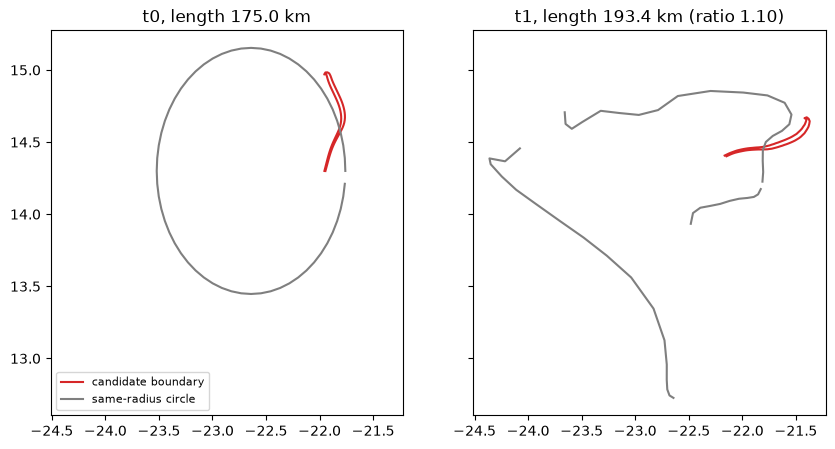

In [24]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
ax0.set_title(f"t0, length {len0 / 1000:.1f} km")
ax0.plot(boundary["lon"], boundary["lat"], color="tab:red", label="candidate boundary")
ax0.plot(circle_lon, circle_lat, color="tab:grey", label="same-radius circle")
ax0.legend(fontsize=8)
evolved_boundary = forward.image(
    lon_0=xr.DataArray(boundary["lon"], dims="point"),
    lat_0=xr.DataArray(boundary["lat"], dims="point"),
)
evolved_circle = forward.image(
    lon_0=xr.DataArray(circle_lon, dims="point"),
    lat_0=xr.DataArray(circle_lat, dims="point"),
)
ax1.set_title(f"t1, length {len1 / 1000:.1f} km (ratio {ratio:.2f})")
ax1.plot(evolved_boundary["lon"], evolved_boundary["lat"], color="tab:red")
ax1.plot(evolved_circle["lon"], evolved_circle["lat"], color="tab:grey")
plt.show()